# Pairwise conflict — a first example

This notebook runs one **pairwise encounter** end to end: a multirotor and a fixed-wing whose straight legs would cross, with conflict detection, resolution, and recovery keeping them apart. We run it once with perfect information, once with GNSS position noise, and finish with a small Monte-Carlo sweep to see how often separation is lost.

Everything here uses only the public API — nothing from `scripts/`. If you have installed the package, it should run top to bottom without changes.

In [1]:
# OpenCDaRR is not on PyPI — install it from your local clone (editable), so source changes
# take effect without reinstalling. The 'examples' extra adds matplotlib + a Jupyter kernel.
#
# Recommended: run this once in a terminal from the repository root:
#     pip install -e ".[examples]"
#
# Or from inside this notebook (examples/ is one level below the repo root), uncomment:
# %pip install -e "..[examples]"

## 1. Build the encounter

A single aircraft is an `Agent`: its state (where it is, how fast) plus the strategy objects that move it — a performance envelope, a dynamics model, and an autopilot flying to a waypoint. `create_conflict` places the fixed-wing so the two legs lose separation 30 s from now, crossing at 90°.

In [8]:
%matplotlib inline

from opencdarr.dynamics import FixedWing, Multirotor
from opencdarr.fleet import Agent, run_fleet
from opencdarr.mission import Mission
from opencdarr.autopilot import WaypointAutopilot
from opencdarr.performance import M600, SMALL_FIXEDWING
from opencdarr.scenario import create_conflict
from opencdarr.state import AircraftState
from opencdarr import geo

# the multirotor cruises due north; the fixed-wing is placed to cross it
copter = AircraftState(id="COPTER", lat=52.0, lon=4.0, trk=0.0, gs=18.0, yaw=0.0)
plane = create_conflict(copter, intr_id="PLANE", dpsi=90.0, dcpa=0.0,
                        tlos=30.0, rpz=50.0, gs_intr=15.0, side=1)

# each aircraft's waypoint sits 800 m straight down its own track
wp_copter = geo.forward(copter.lat, copter.lon, copter.trk, 800.0)
wp_plane = geo.forward(plane.lat, plane.lon, plane.trk, 800.0)

agents = [
    Agent(copter, M600, Multirotor(), WaypointAutopilot(Mission(goto=wp_copter))),
    Agent(plane, SMALL_FIXEDWING, FixedWing(),
          WaypointAutopilot(Mission(goto=wp_plane), cruise_airspeed=15.0)),
]
[a.state.id for a in agents]

['COPTER', 'PLANE']

## 2. Run it clean, and look at the trajectories

`run_fleet` steps the encounter to termination. Pass `record=True` and the returned `FleetOutcome` also carries `frames` — the full states log. `opencdarr.viz` is the separate tool that turns that log into a picture: ground tracks on the left, separation over time on the right, with the protected zone (`rpz`) marked and any avoidance shaded.

We also pass `stop_within=100.0` so the run **ends when the aircraft reach their waypoints** (within 100 m), rather than a few seconds after the conflict clears. The fixed-wing *orbits* its final waypoint at ~80 m, so 100 m is comfortably past its loiter radius; the multirotor hovers right on the point. We raise `done_timeout` to 60 s so that conflict-cleared cutoff does not fire first — arrival is what ends the run.

closest approach: 717.7 m   loss of separation: False
run ended at t = 54.5 s


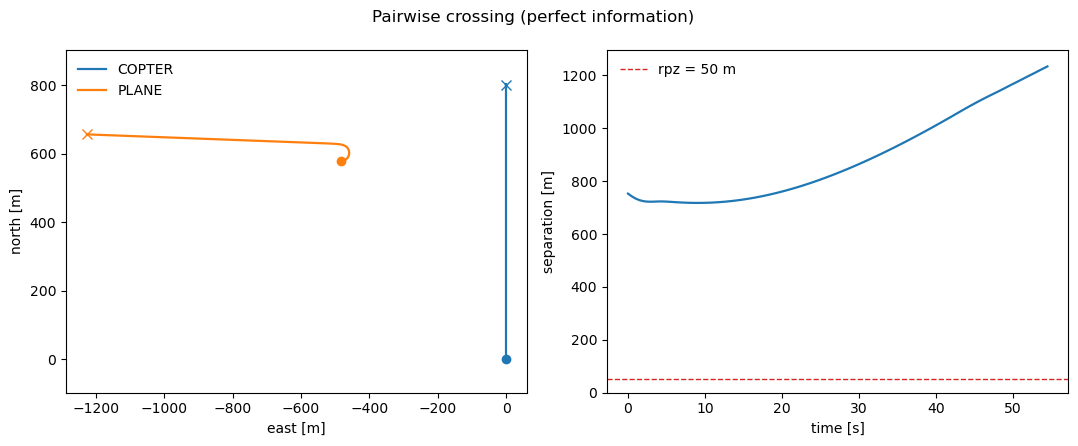

In [9]:
from opencdarr.cd import StateBased
from opencdarr.cr import MVP
from opencdarr.crr import PastCPA
from opencdarr.viz import plot_pairwise

run = run_fleet(
    agents, rpz=50.0, t_lookahead=20.0, dt=0.5,
    detector=StateBased(), resolver=MVP(margin=1.1),
    recovery=PastCPA(bouncing_guard=True),
    stop_within=100.0, done_timeout=60.0,   # stop once both reach their waypoint
    record=True,
)
print(f"closest approach: {run.min_sep:.1f} m   loss of separation: {run.los}")
print(f"run ended at t = {run.frames[-1].t:.1f} s")

fig = plot_pairwise(run, rpz=50.0, title="Pairwise crossing (perfect information)")
# fig.savefig("pairwise_clean.png", dpi=150)   # the figure handle is yours to keep

The closest approach stays above the 50 m protected zone: detection sees the crossing, MVP resolves it, and recovery lets each aircraft return to its waypoint — and now the tracks run all the way to the goal, where the run stops. The orange band on the right marks when an avoidance manoeuvre was active.

## 3. Add CNS uncertainty

Real aircraft do not know their own position exactly. Put a 15 m (95%) GNSS position error on each aircraft and hand `run_fleet` a `GnssNavigation` layer plus a seeded random generator so the run is reproducible. The commanded manoeuvres now act on a noisy self-fix, so the path differs slightly — a different draw of the same encounter.

closest approach: 67.8 m   loss of separation: False


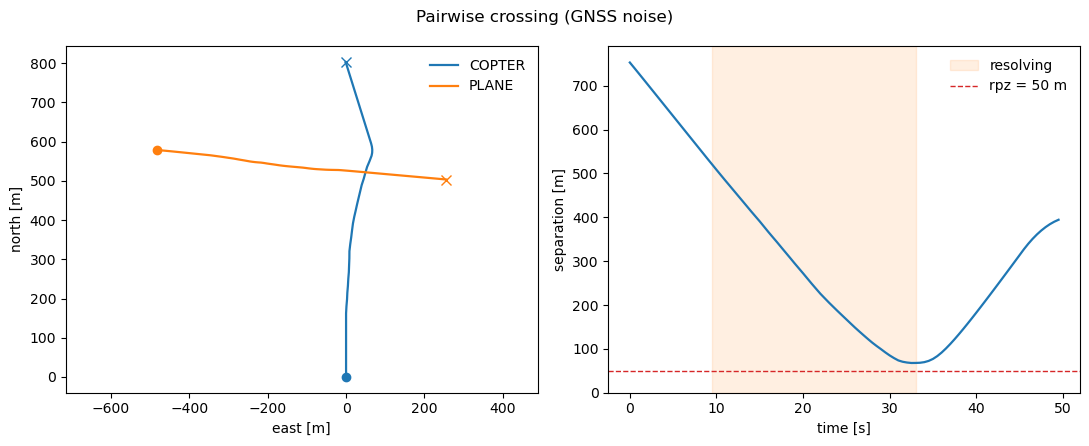

In [4]:
from dataclasses import replace
from opencdarr.cns.navigation import GnssNavigation
from opencdarr import rng

noisy_agents = [replace(a, state=replace(a.state, pos_ci95=15.0, vel_ci95=1.5)) for a in agents]

noisy_run = run_fleet(
    noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.5,
    detector=StateBased(), resolver=MVP(margin=1.1),
    recovery=PastCPA(bouncing_guard=True),
    navigation=GnssNavigation(), rng=rng.generator(rng.root_seed_sequence(20260725)),
    stop_within=100.0, done_timeout=60.0,   # stop once both reach their waypoint
    record=True,
)
print(f"closest approach: {noisy_run.min_sep:.1f} m   loss of separation: {noisy_run.los}")

fig = plot_pairwise(noisy_run, rpz=50.0, title="Pairwise crossing (GNSS noise)")

## 4. Monte Carlo: how often is separation lost?

One noisy run is one draw. To estimate the *rate* of loss of separation, repeat the encounter over many independent noise streams — one RNG substream each, spawned from a single root seed so the whole sweep is reproducible. We record every run (`record=True`) so we can both count outcomes and overlay the trajectories, then read off how many entered the protected zone and how the closest approaches spread.

In [5]:
n_runs = 200
outcomes = [
    run_fleet(
        noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.5,
        detector=StateBased(), resolver=MVP(margin=1.1),
        recovery=PastCPA(bouncing_guard=True),
        navigation=GnssNavigation(), rng=rng.generator(stream),
        stop_within=100.0, done_timeout=60.0,   # each run flies to the waypoint
        record=True,
    )
    for stream in rng.spawn(rng.root_seed_sequence(20260725), n_runs)
]

lost = sum(o.los for o in outcomes)
min_seps = [o.min_sep for o in outcomes]
print(f"loss of separation in {lost}/{n_runs} runs  (rate ~ {lost / n_runs:.3f})")
print(f"closest approach over the sweep: min {min(min_seps):.1f} m, median {sorted(min_seps)[n_runs // 2]:.1f} m")

loss of separation in 0/200 runs  (rate ~ 0.000)
closest approach over the sweep: min 55.1 m, median 83.4 m


Overlay every run's ground tracks with `plot_pairwise_montecarlo`. Each aircraft keeps one colour across all runs, drawn faintly so the *density* of paths shows — the thick core is where the fleet usually goes, the faint threads are the tails. The header carries the sweep's summary: `P(LoS)`, the intrusion-prevention rate (`IPR = 1 - n_los/n_conflict`), and the median closest approach. The east axis is stretched to make the lateral dispersion visible (hence *exaggerated*).

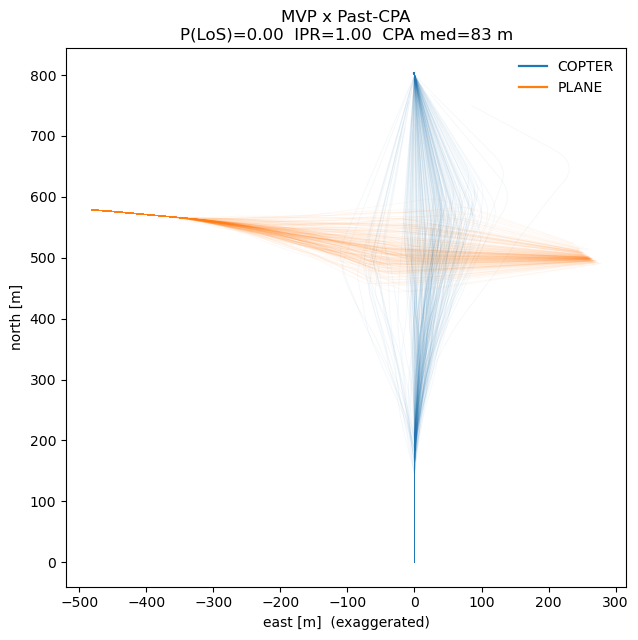

In [6]:
from opencdarr.viz import plot_pairwise_montecarlo

fig = plot_pairwise_montecarlo(outcomes, title="MVP x Past-CPA")

Across these 200 runs separation is never lost — the counted rate is simply 0. That is not the same as *proven safe*: it means 200 samples are too few to observe an event this rare, so Monte Carlo can only say the rate is somewhere below roughly 1/200. The closest-approach spread is the more useful readout here — it shows how much margin the resolver keeps, and how close the tail creeps toward the 50 m zone.

Resolving the genuinely small probabilities that safety targets ask for (of order 10⁻⁹) needs far more than brute-force sampling — that is what the **rare-event simulation** (importance splitting) provides; see the *Rare-event simulation* page in the docs.

From here you can swap any single piece — a different resolver (`VO`), recovery criterion (`FTR`), or airframe — by changing one argument, and re-run the same three views.

## 5. Optional: cache expensive runs

A recorded run carries its full states log, and a heavy encounter (or a whole sweep) can be slow to reproduce just to redraw a figure. `opencdarr.cache` persists a run to disk and reloads it on the next identical request, keyed on the run's parameters + seed + a fingerprint of the `opencdarr` source — so changing the scenario, the seed, or the code invalidates it, and a stale result is never returned.

The pairwise run below is sub-second, so caching buys little *here* — it earns its keep on the expensive fleet and rare-event runs. The pattern is the same:

In [7]:
from opencdarr import cache

params = {"scenario": "pairwise", "pos_ci95": 15.0, "resolver": "mvp", "dt": 0.5}
key = cache.run_key(params, seed=20260725)

def compute():
    return run_fleet(
        noisy_agents, rpz=50.0, t_lookahead=20.0, dt=0.5,
        detector=StateBased(), resolver=MVP(margin=1.1),
        recovery=PastCPA(bouncing_guard=True),
        navigation=GnssNavigation(), rng=rng.generator(rng.root_seed_sequence(20260725)),
        stop_within=100.0, done_timeout=60.0,
        record=True,
    )

run_a = cache.load_or_run(key, compute)  # first call: computes and stores
run_b = cache.load_or_run(key, compute)  # second call: loaded from disk, not recomputed
print(f"key {key}")
print(f"same run reloaded: {run_a.min_sep == run_b.min_sep} (min_sep {run_b.min_sep:.1f} m)")

key 4dcd6e5d884fe2d4ba0e1f1b41878df5
same run reloaded: True (min_sep 67.8 m)
